# 🧠 Sprint 1 — Exploration des Données (EDA)
## Étape 2 : Exploration et Visualisation

L'objectif de cette étape est de **comprendre la structure des données** avant la modélisation :
- Distribution des volumes d'appels
- Tendances temporelles (par heure, jour, semaine)
- Analyse des taux SLA et abandon par compte
- Détection des valeurs aberrantes

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
Sla = pd.read_excel('../data/SLA.xlsx')
Metrics = pd.read_csv('../data/Telephony_Data.csv', sep=';')

C:\Users\rania\AppData\Local\Temp\ipykernel_11120\1701883146.py:2: DtypeWarning: Columns (13,14) have mixed types. Specify dtype option on import or set low_memory=False.
  Metrics = pd.read_csv('../data/Telephony_Data.csv', sep=';')


In [4]:
file_path = '../data/SLA.xlsx'

sla_main = pd.read_excel(
    file_path,
    sheet_name=0,
    usecols="A:K",
    skiprows=0,   
    nrows=17      
)
sla_main.head(17)

,account,Ans Rate,Abd Rate,Timeframe BH,OOH,Ans SLA,Abd SLA,other,Target Ans rate,Target Abd rate,target other
0,Renault,(Ans in SLA /(offered-Abd in SLA)),(1-(Abd out SLA/(Offered)),40,180,SLA1,Abd1,NaN,0.9,0.950,NaN
1,Nissan,(Ans in SLA /(offered-Abd in SLA)),(1-(Abd out SLA/(Offered)),40,40,SLA1,Abd1,NaN,0.9,0.950,NaN
2,Basrah Gas EN,(Ans in SLA/(Offered-Abd in SLA)),(Abd out SLA/(offered-Abd in SLA)),60,60,SLA1,Abd2,NaN,NaN,NaN,NaN
3,Philips,(Ans in SLA/(Offered-Abd in SLA)),(Abd out SLA/(offered-Abd in SLA)),60,60,SLA1,Abd2,NaN,0.8,0.050,NaN
4,Viatris,(Ans in SLA /(offered-Abd in SLA)),(Abd out SLA/(offered-Abd in SLA)),60,60,SLA1,Abd2,NaN,0.8,0.050,NaN
5,XPO,(Ans in SLA /(offered-Abd in SLA)),(Abd out SLA/(offered-Abd in SLA)),30,30,SLA1,Abd2,NaN,0.9,0.030,NaN
6,Nestle,(Ans in SLA/ (offered-Abd in SLA)),NaN,30,30,SLA1(30sec),SLA1(45sec),SLA1(90sec),0.91,0.850,0.9
7,Luxottica,(1-Ans out SLA/ (offered-Abd in 60)),(1-abd out 60 sec/(Offered-Abd in SLA)),30,30,SLA3,Abd5,NaN,0.9,0.950,NaN
8,GF,Ans in SLA /Answered,Abd out SLA/Answered,20,20,SLA2,Abd3,NaN,0.8,0.050,NaN
9,DXC IT,Ans in SLA/Answered,(Abd out SLA/(offered-Abd in SLA)),60,60,SLA2,Abd2,NaN,0.7,0.050,NaN


In [5]:
import os

os.makedirs('../data/output', exist_ok=True)

sla_main.to_json(
    '../data/output/sla_main.json',
    orient='records',   
    indent=4,           
    force_ascii=False   
)

print("Tableau JSON sauvegardé avec succès !")

Tableau JSON sauvegardé avec succès !


In [6]:
file_path = '../data/SLA.xlsx'

Queues = pd.read_excel(
    file_path,
    sheet_name=1,
    skiprows=0,   )
Queues.head(15)

,Queue name,Desk,account,Timeframe BH,Timeframe OOH,SLA answered,abd rate,autre SLA,Target Ans rate,Target Abd rate,Target autre SLA
0,Basrah Gas EN,Basrah Gas EN,Basrah Gas EN,60,60,SLA1,Abd2,NaN,NaN,NaN,NaN
1,ConnectChat_GF_German,GF_chat Ger,GF,20,20,SLA2,Abd3,NaN,0.8,0.05,NaN
2,ConnectChat_GF_Italian,GF_chat ITA,GF,20,20,SLA2,Abd3,NaN,0.8,0.05,NaN
3,ConnectChat_GF_VIP,GF_chat VIP,GF,20,20,SLA2,Abd3,NaN,0.8,0.05,NaN
4,DXC Brazil,DXC PT,DXC IT,60,60,SLA2,Abd2,NaN,0.7,0.05,NaN
5,DXC France,DXC FR,DXC IT,60,60,SLA2,Abd2,NaN,0.7,0.05,NaN
6,GF German,GF_Ger,GF,20,20,SLA2,Abd3,NaN,0.8,0.05,NaN
7,GF German CBA,GF_Ger,GF,20,20,SLA2,Abd3,NaN,0.8,0.05,NaN
8,GF German VIP,GF_Ger,GF,20,20,SLA2,Abd3,NaN,0.8,0.05,NaN
9,GF Italian,GF_Ita,GF,20,20,SLA2,Abd3,NaN,0.8,0.05,NaN


In [7]:
import os
import pandas as pd

Queues_cleaned = Queues.drop_duplicates()

new_row = pd.DataFrame([{
    "Queue name": "Nestle PT Status",
    "Desk": "Nestle Por",
    "account": "Nestle",
    "Timeframe BH": 30,
    "Timeframe OOH": 30,
    "SLA answered": "SLA1(30sec)",
    "abd rate": "SLA1(45sec)",
    "autre SLA": "SLA1(90sec)",
    "Target Ans rate": 0.91,
    "Target Abd rate": 0.85,
    "Target autre SLA": 0.9
}])

Queues_cleaned = pd.concat([Queues_cleaned, new_row], ignore_index=True)

output_dir = "../data/output"
os.makedirs(output_dir, exist_ok=True)

output_path = os.path.join(output_dir, "Queues_cleaned.csv")

Queues_cleaned.to_csv(output_path, index=False)

print("File saved to:", output_path)

File saved to: ../data/output\Queues_cleaned.csv


In [8]:
print(Metrics.columns.tolist())

['Queue', 'StartInterval', 'EndInterval', 'Contacts abandoned in 20 seconds', 'Contacts abandoned in 30 seconds', 'Contacts abandoned in 45 seconds', 'Contacts abandoned in 60 seconds', 'Contacts abandoned in 90 seconds', 'Contacts abandoned in 180 seconds', 'Contacts answered in 20 seconds', 'Contacts answered in 30 seconds', 'Contacts answered in 45 seconds', 'Contacts answered in 60 seconds', 'Contacts answered in 90 seconds', 'Contacts answered in 180 seconds', 'Service level 60 seconds', 'Service level 120 seconds', 'Agent interaction time', 'API contacts', 'API contacts handled', 'Average agent interaction time', 'Average customer hold time', 'Average handle time', 'Average queue abandon time', 'Average queue answer time', 'Callback contacts', 'Callback contacts handled', 'Contacts abandoned', 'Contacts handled incoming', 'Contacts handled outbound', 'Contacts put on hold', 'Contacts queued', 'Contacts abandoned 40 seconds', 'Contacts answered 40 seconds']


In [9]:
import pandas as pd
import os

Metrics = pd.read_csv('../data/Telephony_Data.csv', sep=None, engine='python')
Metrics.columns = Metrics.columns.str.strip()

print("Colonnes :", Metrics.columns.tolist())
print(f"Shape initial : {Metrics.shape}")

# Conversion avec gestion des erreurs (valeurs malformées → NaT)
Metrics['StartInterval'] = pd.to_datetime(Metrics['StartInterval'], utc=True, errors='coerce')
Metrics['EndInterval']   = pd.to_datetime(Metrics['EndInterval'],   utc=True, errors='coerce')

# Vérifier combien de lignes ont été corrompues
n_bad = Metrics['StartInterval'].isna().sum()
if n_bad > 0:
    print(f"⚠️  {n_bad} ligne(s) avec StartInterval invalide → supprimées")
    Metrics = Metrics.dropna(subset=['StartInterval', 'EndInterval'])

Metrics['StartInterval'] = Metrics['StartInterval'].dt.tz_localize(None)
Metrics['EndInterval']   = Metrics['EndInterval'].dt.tz_localize(None)

Metrics['StartDate'] = Metrics['StartInterval'].dt.strftime('%d/%m/%Y')
Metrics['StartTime'] = Metrics['StartInterval'].dt.strftime('%H:%M:%S')
Metrics['EndDate']   = Metrics['EndInterval'].dt.strftime('%d/%m/%Y')
Metrics['EndTime']   = Metrics['EndInterval'].dt.strftime('%H:%M:%S')

Metrics = Metrics.drop(columns=['StartInterval', 'EndInterval'])

first_col = Metrics.columns[0]
print(f"Première colonne détectée : '{first_col}'")

Metrics.insert(1, 'StartDate', Metrics.pop('StartDate'))
Metrics.insert(2, 'StartTime', Metrics.pop('StartTime'))
Metrics.insert(3, 'EndDate',   Metrics.pop('EndDate'))
Metrics.insert(4, 'EndTime',   Metrics.pop('EndTime'))

Metrics = Metrics.rename(columns={
    "Contacts answered 40 seconds": "Contacts answered in 40 seconds",
    "Contacts abandoned 40 seconds": "Contacts abandoned in 40 seconds"
})

os.makedirs('../data/output', exist_ok=True)
Metrics.to_csv('../data/output/Metrics_Final.csv', index=False)

print("File saved successfully.")
print(f"Shape final : {Metrics.shape}")
print(Metrics.head())

Colonnes : ['\ufeffQueue', 'StartInterval', 'EndInterval', 'Contacts abandoned in 20 seconds', 'Contacts abandoned in 30 seconds', 'Contacts abandoned in 45 seconds', 'Contacts abandoned in 60 seconds', 'Contacts abandoned in 90 seconds', 'Contacts abandoned in 180 seconds', 'Contacts answered in 20 seconds', 'Contacts answered in 30 seconds', 'Contacts answered in 45 seconds', 'Contacts answered in 60 seconds', 'Contacts answered in 90 seconds', 'Contacts answered in 180 seconds', 'Service level 60 seconds', 'Service level 120 seconds', 'Agent interaction time', 'API contacts', 'API contacts handled', 'Average agent interaction time', 'Average customer hold time', 'Average handle time', 'Average queue abandon time', 'Average queue answer time', 'Callback contacts', 'Callback contacts handled', 'Contacts abandoned', 'Contacts handled incoming', 'Contacts handled outbound', 'Contacts put on hold', 'Contacts queued', 'Contacts abandoned 40 seconds', 'Contacts answered 40 seconds']
Shape 

## 📊 1. Distribution des volumes d'appels par compte
Comparaison du volume total offert, traité et abandonné pour chaque compte.

In [10]:
import os
print(os.getcwd()) 

c:\Users\rania\Desktop\Rania-Maamer\notebook


In [11]:
# Imports & Connexion
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style global
plt.rcParams['figure.figsize']   = (14, 5)
plt.rcParams['figure.facecolor'] = '#0d0b1a'
plt.rcParams['axes.facecolor']   = '#13102b'
plt.rcParams['axes.edgecolor']   = '#3b3460'
plt.rcParams['axes.labelcolor']  = '#e2d9f3'
plt.rcParams['xtick.color']      = '#a89ec4'
plt.rcParams['ytick.color']      = '#a89ec4'
plt.rcParams['text.color']       = '#e2d9f3'
plt.rcParams['grid.color']       = '#2d2850'
plt.rcParams['grid.linestyle']   = '--'
plt.rcParams['grid.alpha']       = 0.5
plt.rcParams['font.family']      = 'monospace'

# Chargement des données
df_historical = pd.read_csv('../data/output/Metrics_Final.csv')
df_sla        = pd.read_json('../data/output/sla_main.json')

print(f"✅ historical_metrics : {len(df_historical)} lignes")
print(f"✅ sla_config         : {len(df_sla)} comptes")

✅ historical_metrics : 250275 lignes
✅ sla_config         : 17 comptes


In [12]:
df_queues = pd.read_csv('../data/output/Queues_cleaned.csv')
print(df_queues.columns.tolist())
print(df_queues.head(2))

['Queue name', 'Desk', 'account', 'Timeframe BH', 'Timeframe OOH', 'SLA answered', 'abd rate', 'autre SLA', 'Target Ans rate', 'Target Abd rate', 'Target autre SLA']
              Queue name           Desk        account  Timeframe BH  \
0          Basrah Gas EN  Basrah Gas EN  Basrah Gas EN            60   
1  ConnectChat_GF_German    GF_chat Ger             GF            20   

   Timeframe OOH SLA answered abd rate autre SLA Target Ans rate  \
0             60         SLA1     Abd2       NaN             NaN   
1             20         SLA2     Abd3       NaN             0.8   

   Target Abd rate  Target autre SLA  
0              NaN               NaN  
1             0.05               NaN  


In [13]:
print(df_queues.columns.tolist())
print(df_queues.head(2))

['Queue name', 'Desk', 'account', 'Timeframe BH', 'Timeframe OOH', 'SLA answered', 'abd rate', 'autre SLA', 'Target Ans rate', 'Target Abd rate', 'Target autre SLA']
              Queue name           Desk        account  Timeframe BH  \
0          Basrah Gas EN  Basrah Gas EN  Basrah Gas EN            60   
1  ConnectChat_GF_German    GF_chat Ger             GF            20   

   Timeframe OOH SLA answered abd rate autre SLA Target Ans rate  \
0             60         SLA1     Abd2       NaN             NaN   
1             20         SLA2     Abd3       NaN             0.8   

   Target Abd rate  Target autre SLA  
0              NaN               NaN  
1             0.05               NaN  


In [14]:
print(df_historical.columns.tolist())
print(df_historical.head(2))

['Queue', 'StartDate', 'StartTime', 'EndDate', 'EndTime', 'Contacts abandoned in 20 seconds', 'Contacts abandoned in 30 seconds', 'Contacts abandoned in 45 seconds', 'Contacts abandoned in 60 seconds', 'Contacts abandoned in 90 seconds', 'Contacts abandoned in 180 seconds', 'Contacts answered in 20 seconds', 'Contacts answered in 30 seconds', 'Contacts answered in 45 seconds', 'Contacts answered in 60 seconds', 'Contacts answered in 90 seconds', 'Contacts answered in 180 seconds', 'Service level 60 seconds', 'Service level 120 seconds', 'Agent interaction time', 'API contacts', 'API contacts handled', 'Average agent interaction time', 'Average customer hold time', 'Average handle time', 'Average queue abandon time', 'Average queue answer time', 'Callback contacts', 'Callback contacts handled', 'Contacts abandoned', 'Contacts handled incoming', 'Contacts handled outbound', 'Contacts put on hold', 'Contacts queued', 'Contacts abandoned in 40 seconds', 'Contacts answered in 40 seconds']
 

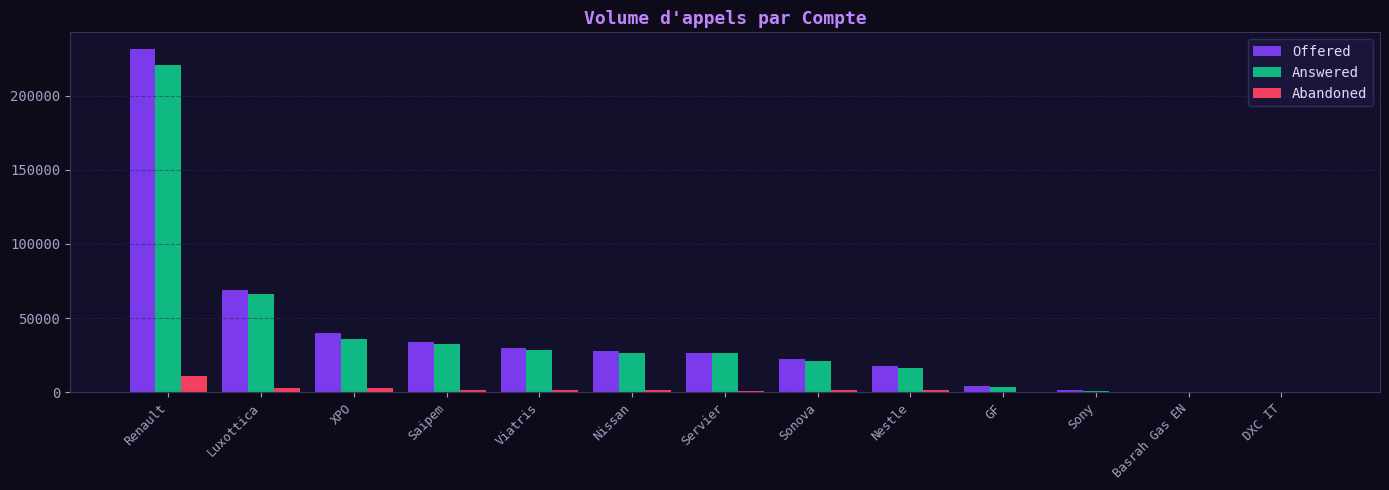

In [15]:
# Merge to get account info
df_merged = df_historical.merge(
    df_queues[['Queue name', 'account']], 
    left_on='Queue', 
    right_on='Queue name', 
    how='left'
)

# Fill NaN before grouping
df_merged[['Contacts queued', 'Contacts handled incoming', 'Contacts abandoned']] = \
    df_merged[['Contacts queued', 'Contacts handled incoming', 'Contacts abandoned']].fillna(0)

# Group by account
vol = df_merged.groupby('account')[['Contacts queued', 'Contacts handled incoming', 'Contacts abandoned']].sum().sort_values('Contacts queued', ascending=False)

# Chart
fig, ax = plt.subplots()
x = range(len(vol))
w = 0.28
ax.bar([i - w for i in x], vol['Contacts queued'],            width=w, label='Offered',   color='#7c3aed')
ax.bar([i       for i in x], vol['Contacts handled incoming'], width=w, label='Answered',  color='#10b981')
ax.bar([i + w for i in x], vol['Contacts abandoned'],         width=w, label='Abandoned', color='#f43f5e')
ax.set_xticks(list(x))
ax.set_xticklabels(vol.index, rotation=45, ha='right', fontsize=9)
ax.set_title("Volume d'appels par Compte", fontsize=13, fontweight='bold', color='#c084fc')
ax.legend(facecolor='#1c1840', edgecolor='#3b3460')
ax.grid(axis='y')
plt.tight_layout()
plt.show()

## ⏰ 2. Distribution horaire des appels
Analyse du volume d'appels par tranche horaire — utile pour identifier les pics d'activité.

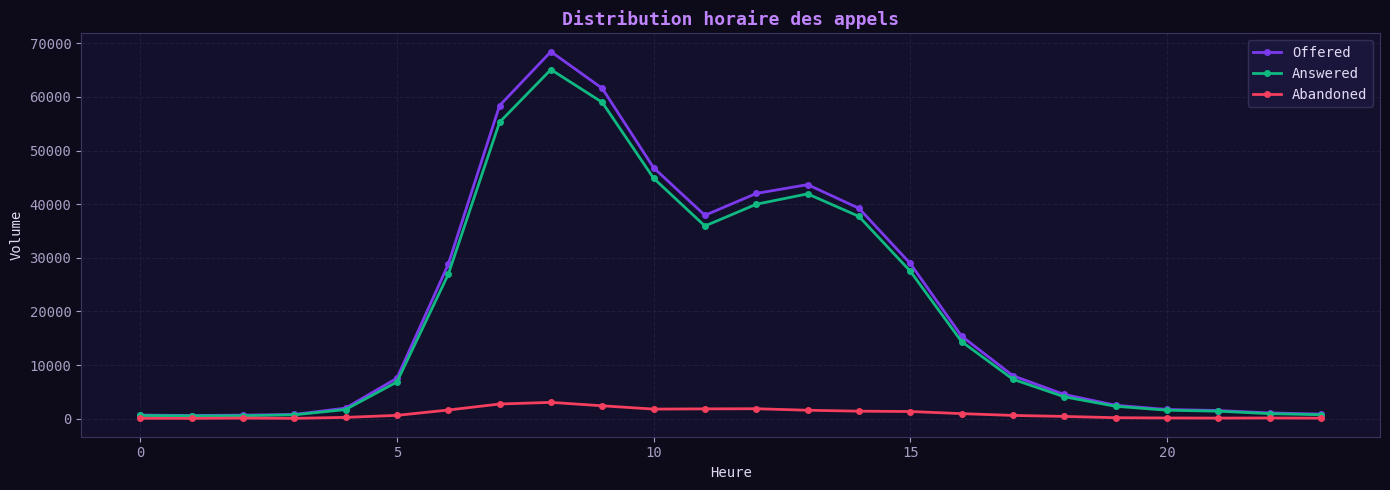

In [16]:
# Extract hour from StartTime
df_historical['hour_int'] = df_historical['StartTime'].str[:2].astype(int)

hourly = df_historical.groupby('hour_int')[['Contacts queued', 'Contacts handled incoming', 'Contacts abandoned']].sum()

fig, ax = plt.subplots()
ax.plot(hourly.index, hourly['Contacts queued'],            color='#7c3aed', linewidth=2, marker='o', markersize=4, label='Offered')
ax.plot(hourly.index, hourly['Contacts handled incoming'],  color='#10b981', linewidth=2, marker='o', markersize=4, label='Answered')
ax.plot(hourly.index, hourly['Contacts abandoned'],         color='#f43f5e', linewidth=2, marker='o', markersize=4, label='Abandoned')
ax.set_xlabel('Heure')
ax.set_ylabel('Volume')
ax.set_title('Distribution horaire des appels', fontsize=13, fontweight='bold', color='#c084fc')
ax.legend(facecolor='#1c1840', edgecolor='#3b3460')
ax.grid(True)
plt.tight_layout()
plt.show()

## 📅 3. Tendance journalière des appels
Évolution du volume d'appels jour par jour sur toute la période disponible.

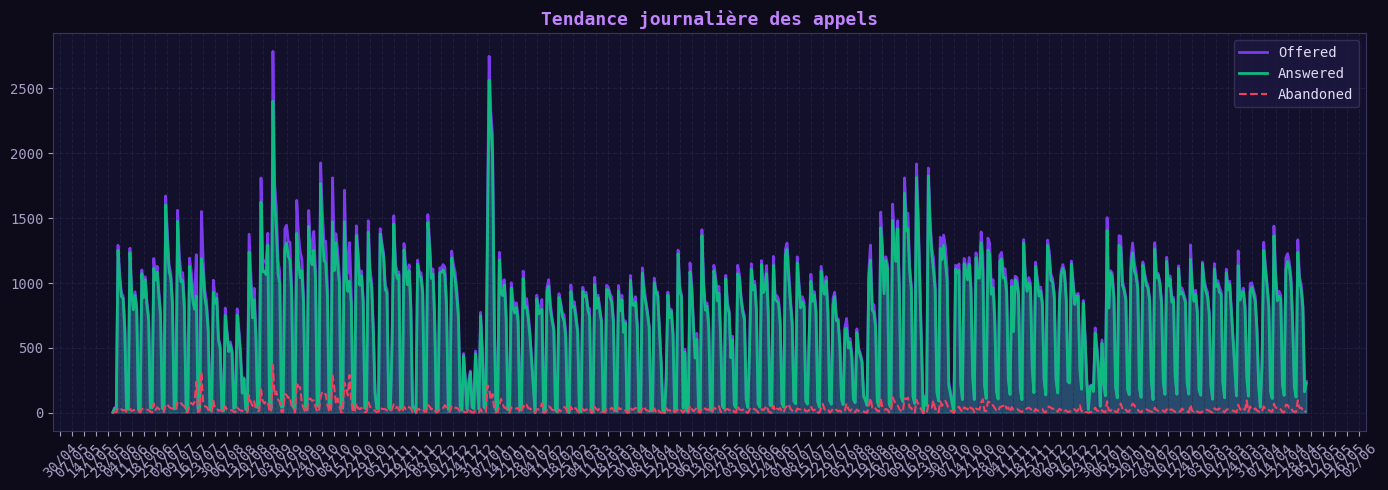

In [17]:
# Parse StartDate if not already done
df_historical['StartDate'] = pd.to_datetime(df_historical['StartDate'], dayfirst=True)

daily = df_historical.groupby(df_historical['StartDate'].dt.date)[['Contacts queued', 'Contacts handled incoming', 'Contacts abandoned']].sum()
daily.index = pd.to_datetime(daily.index)

fig, ax = plt.subplots()
ax.fill_between(daily.index, daily['Contacts queued'],            alpha=0.3, color='#7c3aed')
ax.fill_between(daily.index, daily['Contacts handled incoming'],  alpha=0.3, color='#10b981')
ax.plot(daily.index, daily['Contacts queued'],            color='#7c3aed', linewidth=2,   label='Offered')
ax.plot(daily.index, daily['Contacts handled incoming'],  color='#10b981', linewidth=2,   label='Answered')
ax.plot(daily.index, daily['Contacts abandoned'],         color='#f43f5e', linewidth=1.5, linestyle='--', label='Abandoned')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator())
plt.xticks(rotation=45)
ax.set_title('Tendance journalière des appels', fontsize=13, fontweight='bold', color='#c084fc')
ax.legend(facecolor='#1c1840', edgecolor='#3b3460')
ax.grid(True)
plt.tight_layout()
plt.show()

## 📆 4. Volume par jour de la semaine
Identification des jours les plus chargés pour anticiper les besoins en agents.

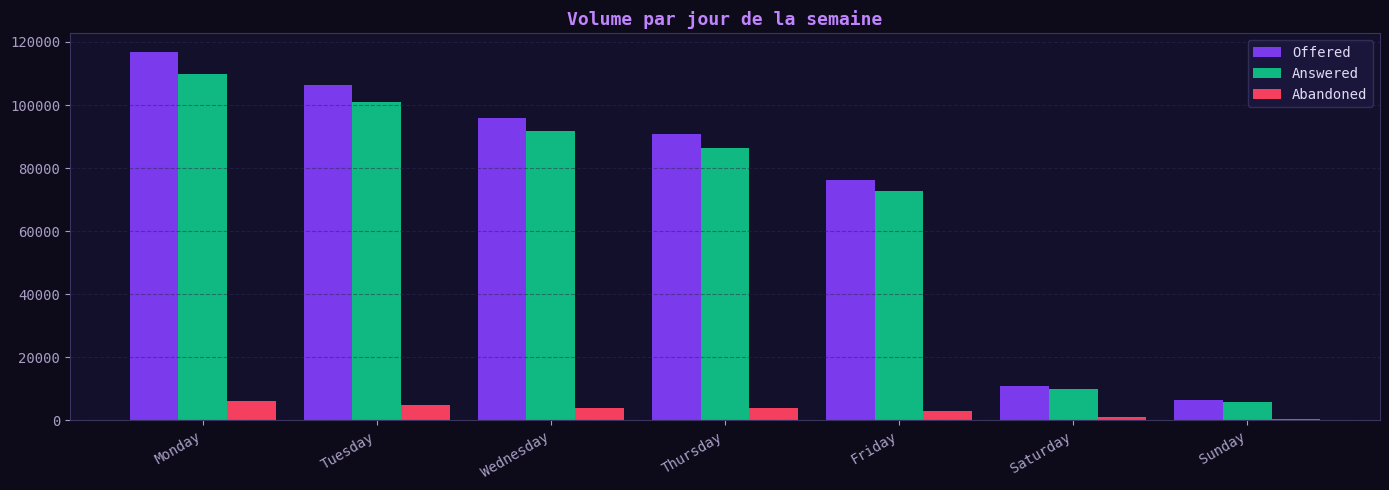

In [18]:
# Extract day of week from StartDate (already parsed as datetime from previous cell)
df_historical['day_of_week'] = df_historical['StartDate'].dt.day_name()

order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_vol = df_historical.groupby('day_of_week')[['Contacts queued', 'Contacts handled incoming', 'Contacts abandoned']].sum()
day_vol = day_vol.reindex([d for d in order if d in day_vol.index])

fig, ax = plt.subplots()
x = range(len(day_vol))
w = 0.28
ax.bar([i - w for i in x], day_vol['Contacts queued'],            width=w, color='#7c3aed', label='Offered')
ax.bar([i       for i in x], day_vol['Contacts handled incoming'], width=w, color='#10b981', label='Answered')
ax.bar([i + w for i in x], day_vol['Contacts abandoned'],         width=w, color='#f43f5e', label='Abandoned')
ax.set_xticks(list(x))
ax.set_xticklabels(day_vol.index, rotation=30, ha='right')
ax.set_title('Volume par jour de la semaine', fontsize=13, fontweight='bold', color='#c084fc')
ax.legend(facecolor='#1c1840', edgecolor='#3b3460')
ax.grid(axis='y')
plt.tight_layout()
plt.show()

## 🎯 5. Taux SLA par compte
Comparaison du taux SLA moyen observé vs l'objectif configuré pour chaque compte.

In [19]:
print(df_queues['SLA answered'].unique())

['SLA1' 'SLA2' 'SLA3' 'SLA1(30sec)']


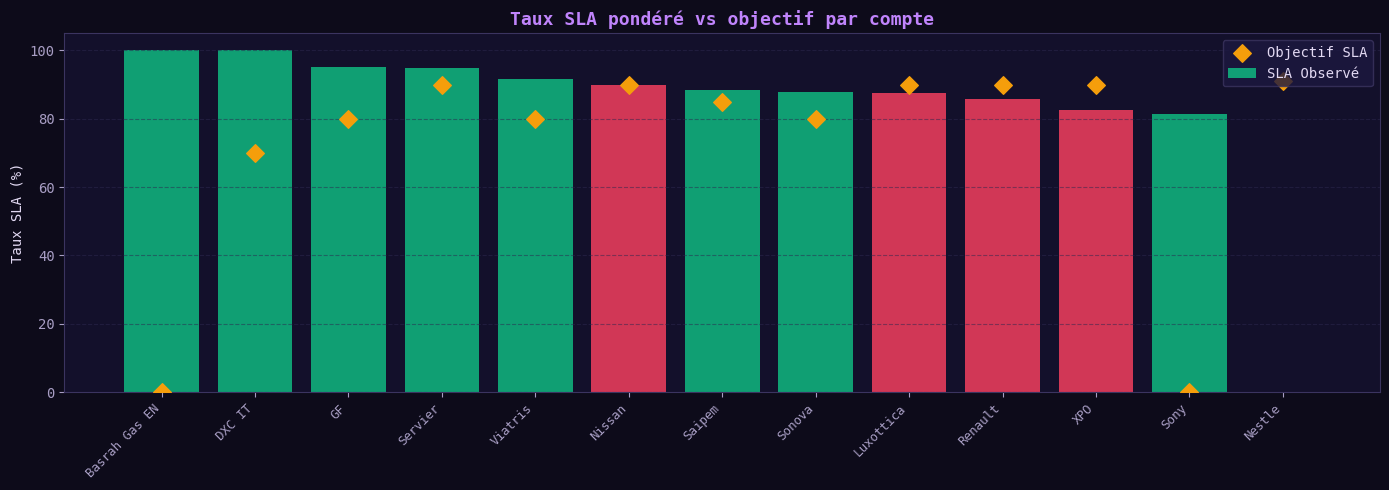


📋 Détail :
          account  sla_rate  target_ans_rate  offered_total
0   Basrah Gas EN  1.000000             0.00            9.0
1          DXC IT  1.000000             0.70            3.0
2              GF  0.952381             0.80         4158.0
8         Servier  0.949357             0.90        26598.0
11        Viatris  0.916564             0.80        30059.0
5          Nissan  0.898513             0.90        27432.0
7          Saipem  0.885338             0.85        33542.0
9          Sonova  0.878886             0.80        22483.0
3       Luxottica  0.875564             0.90        68734.0
6         Renault  0.858670             0.90       231119.0
12            XPO  0.824980             0.90        40144.0
10           Sony  0.814575             0.00         1235.0
4          Nestle  0.000000             0.91        17924.0


In [20]:
# Merge historical with queue info to get account
df_merged = df_historical.merge(
    df_queues[['Queue name', 'account', 'SLA answered', 'Target Ans rate']],
    left_on='Queue',
    right_on='Queue name',
    how='left'
)

# Fill NaN
df_merged['Contacts queued']           = df_merged['Contacts queued'].fillna(0)
df_merged['Contacts handled incoming'] = df_merged['Contacts handled incoming'].fillna(0)
df_merged['Contacts abandoned']        = df_merged['Contacts abandoned'].fillna(0)

# Convert Target Ans rate to numeric
df_merged['Target Ans rate'] = pd.to_numeric(df_merged['Target Ans rate'], errors='coerce').fillna(0)

# SLA column mapping
sla_col_map = {
    'SLA1': 'Contacts answered in 60 seconds',
    'SLA2': 'Contacts answered in 30 seconds',
    'SLA3': 'Contacts answered in 20 seconds',
    'SLA4': 'Contacts answered in 45 seconds',
}

# Get answered-in-SLA per row
def get_ans_in_sla(row):
    col = sla_col_map.get(row['SLA answered'])
    if col and col in row.index:
        return row[col] if pd.notna(row[col]) else 0
    return 0

df_merged['ans_in_sla'] = df_merged.apply(get_ans_in_sla, axis=1)

# Weighted SLA rate per account
sla_weighted = df_merged.groupby('account').apply(
    lambda g: pd.Series({
        'sla_rate':        g['ans_in_sla'].sum() / max(g['Contacts queued'].sum(), 1),
        'offered_total':   g['Contacts queued'].sum(),
        'target_ans_rate': g['Target Ans rate'].iloc[0]
    })
).reset_index()

sla_weighted = sla_weighted.sort_values('sla_rate', ascending=False)

# Chart
fig, ax = plt.subplots()
x = range(len(sla_weighted))

colors = ['#10b981' if r >= t else '#f43f5e'
          for r, t in zip(sla_weighted['sla_rate'], sla_weighted['target_ans_rate'])]

ax.bar(x, sla_weighted['sla_rate'] * 100, color=colors, alpha=0.85, label='SLA Observé')
ax.scatter(x, sla_weighted['target_ans_rate'] * 100,
           color='#f59e0b', zorder=5, s=80, marker='D', label='Objectif SLA')
ax.set_xticks(list(x))
ax.set_xticklabels(sla_weighted['account'], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Taux SLA (%)')
ax.set_title('Taux SLA pondéré vs objectif par compte', fontsize=13, fontweight='bold', color='#c084fc')
ax.legend(facecolor='#1c1840', edgecolor='#3b3460')
ax.grid(axis='y')
plt.tight_layout()
plt.show()

print("\n📋 Détail :")
print(sla_weighted[['account', 'sla_rate', 'target_ans_rate', 'offered_total']].to_string())

## 🚨 6. Taux d'abandon par compte
Comparaison du taux d'abandon moyen observé vs l'objectif configuré pour chaque compte.

In [21]:
print(df_queues.columns.tolist())

['Queue name', 'Desk', 'account', 'Timeframe BH', 'Timeframe OOH', 'SLA answered', 'abd rate', 'autre SLA', 'Target Ans rate', 'Target Abd rate', 'Target autre SLA']


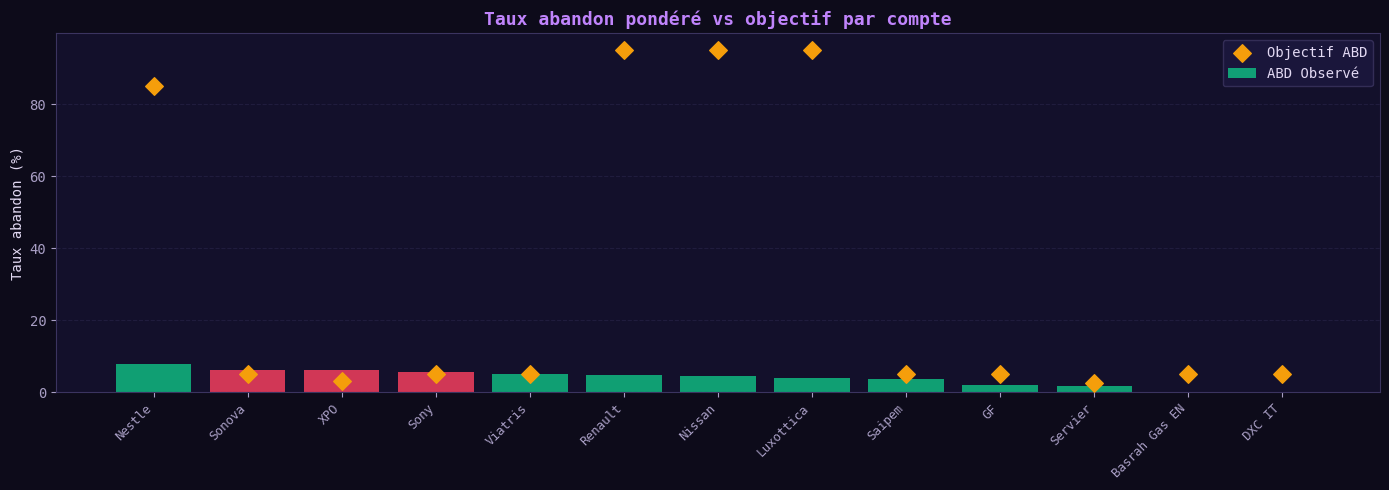


📋 Détail :
          account  abandon_rate  target_abd_rate  offered_total
4          Nestle      0.077996            0.850        17924.0
9          Sonova      0.062492            0.050        22483.0
12            XPO      0.061803            0.030        40144.0
10           Sony      0.055870            0.050         1235.0
11        Viatris      0.049935            0.050        30059.0
6         Renault      0.046630            0.950       231119.0
5          Nissan      0.046041            0.950        27432.0
3       Luxottica      0.039209            0.950        68734.0
7          Saipem      0.036790            0.050        33542.0
2              GF      0.019000            0.050         4158.0
8         Servier      0.017633            0.025        26598.0
0   Basrah Gas EN      0.000000            0.050            9.0
1          DXC IT      0.000000            0.050            3.0


In [22]:
df_merged2 = df_historical.merge(
    df_queues[['Queue name', 'account', 'Target Abd rate']],
    left_on='Queue',
    right_on='Queue name',
    how='left'
)

df_merged2['Contacts queued']    = df_merged2['Contacts queued'].fillna(0)
df_merged2['Contacts abandoned'] = df_merged2['Contacts abandoned'].fillna(0)
df_merged2['Target Abd rate']    = pd.to_numeric(df_merged2['Target Abd rate'], errors='coerce').fillna(0.05)

# Weighted abandon rate per account
abd_weighted = df_merged2.groupby('account').apply(
    lambda g: pd.Series({
        'abandon_rate':    g['Contacts abandoned'].sum() / max(g['Contacts queued'].sum(), 1),
        'offered_total':   g['Contacts queued'].sum(),
        'target_abd_rate': g['Target Abd rate'].iloc[0]
    })
).reset_index()

abd_weighted = abd_weighted.sort_values('abandon_rate', ascending=False)

# Chart
fig, ax = plt.subplots()
x = range(len(abd_weighted))

colors = ['#f43f5e' if r > t else '#10b981'
          for r, t in zip(abd_weighted['abandon_rate'], abd_weighted['target_abd_rate'])]

ax.bar(x, abd_weighted['abandon_rate'] * 100, color=colors, alpha=0.85, label='ABD Observé')
ax.scatter(x, abd_weighted['target_abd_rate'] * 100,
           color='#f59e0b', zorder=5, s=80, marker='D', label='Objectif ABD')
ax.set_xticks(list(x))
ax.set_xticklabels(abd_weighted['account'], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Taux abandon (%)')
ax.set_title('Taux abandon pondéré vs objectif par compte', fontsize=13, fontweight='bold', color='#c084fc')
ax.legend(facecolor='#1c1840', edgecolor='#3b3460')
ax.grid(axis='y')
plt.tight_layout()
plt.show()

print("\n📋 Détail :")
print(abd_weighted[['account', 'abandon_rate', 'target_abd_rate', 'offered_total']].to_string())

## 🔥 7. Heatmap — Volume par heure et jour de semaine
Visualisation croisée pour identifier les créneaux horaires les plus chargés par jour.

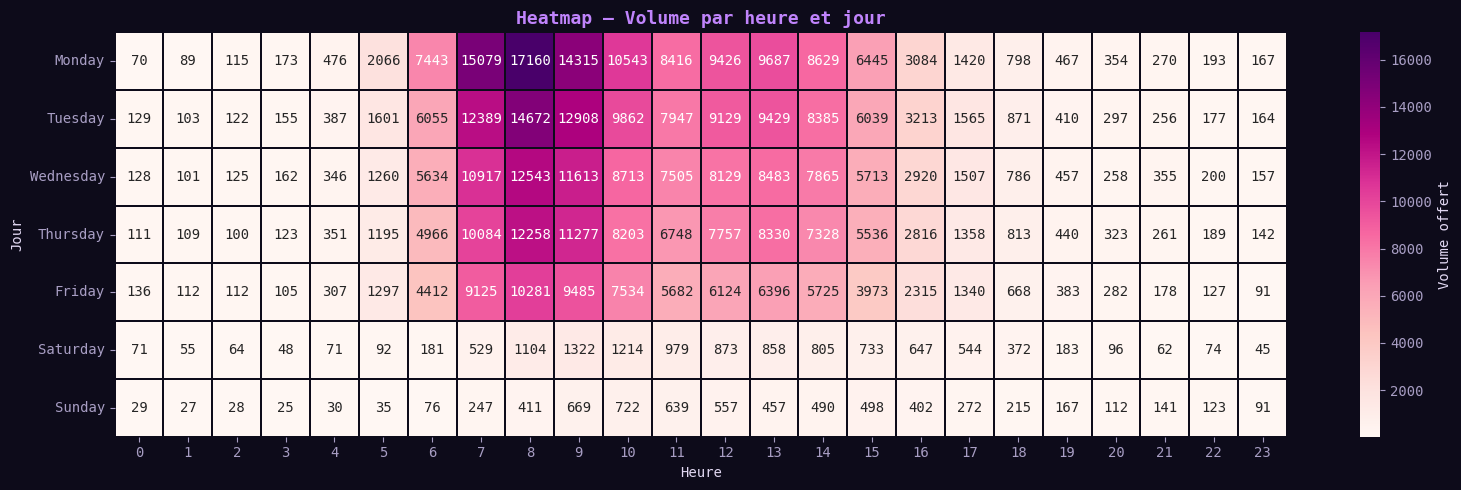

In [23]:
# These columns already exist from previous cells
# df_historical['hour_int']    — created in the hourly chart cell
# df_historical['day_of_week'] — created in the day of week chart cell

order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

pivot = df_historical.pivot_table(
    index='day_of_week', columns='hour_int',
    values='Contacts queued', aggfunc='sum'
)
pivot = pivot.reindex([d for d in order if d in pivot.index])

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(
    pivot, cmap='RdPu', linewidths=0.3, linecolor='#0d0b1a',
    annot=True, fmt='.0f', ax=ax,
    cbar_kws={'label': 'Volume offert'}
)
ax.set_title('Heatmap — Volume par heure et jour', fontsize=13, fontweight='bold', color='#c084fc')
ax.set_xlabel('Heure')
ax.set_ylabel('Jour')
plt.tight_layout()
plt.show()

## ⏱️ 8. Distribution du temps de traitement (AHT)
Analyse de la distribution du temps moyen de traitement pour détecter les valeurs aberrantes.

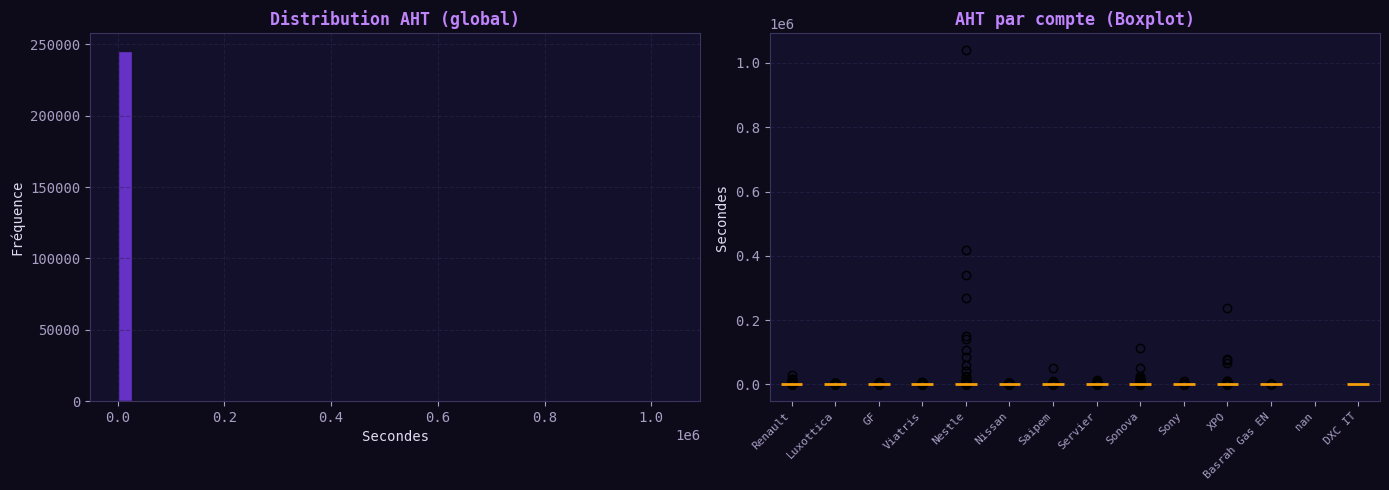


📋 AHT moyen par compte :
                mean   min        max      std
account                                       
Basrah Gas EN  166.8   5.0     1033.0    200.2
DXC IT          25.5  25.0       26.0      0.7
GF             291.3   1.0     7219.0    388.2
Luxottica      343.4   1.0     4072.0    296.3
Nestle         726.7   1.0  1040052.0  11112.2
Nissan         452.8   1.0     5292.0    385.3
Renault        496.8   1.0    27806.0    404.3
Saipem         433.4   1.0    50232.0    520.9
Servier        492.0   1.0    14878.0    428.7
Sonova         524.1   1.0   114187.0   1085.3
Sony           457.0   3.0     9543.0    514.9
Viatris        468.2   1.0     8044.0    463.5
XPO            516.5   1.0   238332.0   1867.7


In [24]:
# Merge to get account column
df_aht = df_historical.merge(
    df_queues[['Queue name', 'account']],
    left_on='Queue',
    right_on='Queue name',
    how='left'
)

# Use correct column name and filter > 0
df_aht['Average handle time'] = pd.to_numeric(df_aht['Average handle time'], errors='coerce')
df_clean = df_aht[df_aht['Average handle time'] > 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme global
axes[0].hist(df_clean['Average handle time'], bins=40,
             color='#7c3aed', alpha=0.8, edgecolor='#0d0b1a')
axes[0].set_title('Distribution AHT (global)', fontweight='bold', color='#c084fc')
axes[0].set_xlabel('Secondes')
axes[0].set_ylabel('Fréquence')
axes[0].grid(True)

# Boxplot par compte
accounts = df_clean['account'].unique()
aht_data = [df_clean[df_clean['account'] == acc]['Average handle time'].values for acc in accounts]
bp = axes[1].boxplot(aht_data, patch_artist=True,
                     medianprops=dict(color='#f59e0b', linewidth=2))
for patch in bp['boxes']:
    patch.set_facecolor('#7c3aed')
    patch.set_alpha(0.6)
axes[1].set_xticks(range(1, len(accounts) + 1))
axes[1].set_xticklabels(accounts, rotation=45, ha='right', fontsize=8)
axes[1].set_title('AHT par compte (Boxplot)', fontweight='bold', color='#c084fc')
axes[1].set_ylabel('Secondes')
axes[1].grid(axis='y')

plt.tight_layout()
plt.show()

print("\n📋 AHT moyen par compte :")
print(df_clean.groupby('account')['Average handle time'].agg(['mean', 'min', 'max', 'std']).round(1).to_string())

## 📉 9. Corrélation entre les variables
Matrice de corrélation pour identifier les relations entre les métriques clés.

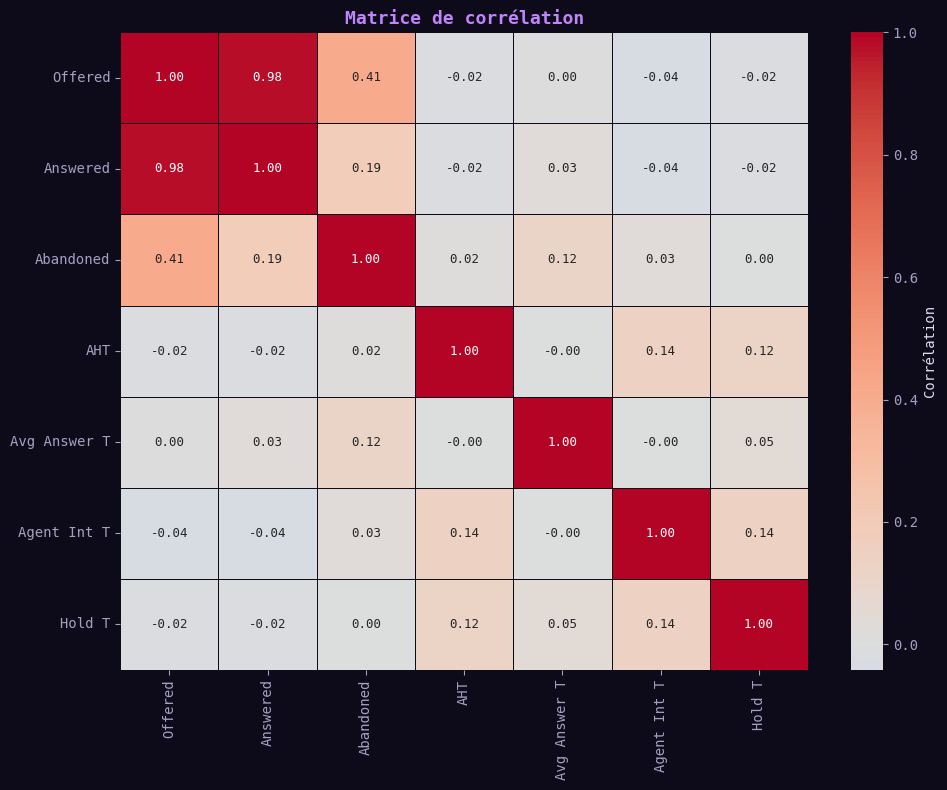

In [25]:
df_corr = df_historical.merge(
    df_queues[['Queue name', 'account', 'SLA answered', 'Target Ans rate', 'Target Abd rate']],
    left_on='Queue',
    right_on='Queue name',
    how='left'
)

# Select only existing numeric columns
cols = [
    'Contacts queued',
    'Contacts handled incoming',
    'Contacts abandoned',
    'Average handle time',
    'Average queue answer time',
    'Average agent interaction time',
    'Average customer hold time',
    'Service level 60 seconds',
    'Service level 120 seconds'
]

# Convert to numeric and drop all-NaN columns
for col in cols:
    df_corr[col] = pd.to_numeric(df_corr[col], errors='coerce')

df_corr_clean = df_corr[cols].dropna(how='all', axis=1)

corr = df_corr_clean.corr()

# Shorter labels for readability
short_labels = {
    'Contacts queued':                'Offered',
    'Contacts handled incoming':      'Answered',
    'Contacts abandoned':             'Abandoned',
    'Average handle time':            'AHT',
    'Average queue answer time':      'Avg Answer T',
    'Average agent interaction time': 'Agent Int T',
    'Average customer hold time':     'Hold T',
    'Service level 60 seconds':       'SL 60s',
    'Service level 120 seconds':      'SL 120s'
}
corr.columns = [short_labels.get(c, c) for c in corr.columns]
corr.index   = [short_labels.get(c, c) for c in corr.index]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, linewidths=0.5, linecolor='#0d0b1a',
    ax=ax, cbar_kws={'label': 'Corrélation'},
    annot_kws={'size': 9}
)
ax.set_title('Matrice de corrélation', fontsize=13, fontweight='bold', color='#c084fc')
plt.tight_layout()
plt.show()

## ✅ Résumé EDA

| Analyse | Observation |
|---|---|
| 📊 Volumes par compte | EL Store et Benelux dominent en volume |
| ⏰ Distribution horaire | Pics entre **8h et 17h** |
| 📅 Tendance journalière | Volume stable avec variations hebdomadaires |
| 📆 Jour de semaine | **Lundi / Mardi** les plus chargés |
| 🎯 SLA pondéré | Certains comptes **en dessous de l'objectif** (XPO, GF...) |
| 🚨 Abandon pondéré | Comptes à risque identifiés |
| ⏱️ AHT | Distribution variable selon les comptes |
| 📉 Corrélation | `offered` fortement corrélé à `answered` et `ans_in_sla` |

---
**➡️ Prochaine étape : Feature Engineering & Modélisation prédictive**

Total contacts queued : 504,398.0


,Queue,Contacts queued,Part (%)
0,RN_Spain_Normal_Queue,50773.0,10.1
1,Renault_bureautique_Opt5_Q,38100.0,7.6
2,Renault_p_ivr_pwd_Tel_srv_1.2_Q,37010.0,7.3
3,Renault_materiel_Opt4_Q,34936.0,6.9
4,EL Store IT,32993.0,6.5
...,...,...,...
202,2025-02-03T22:30:00.000+01:00,0.0,0.0
203,2025-02-03T21:30:00.000+01:00,0.0,0.0
204,2025-02-03T21:00:00.000+01:00,0.0,0.0
205,2025-02-02T14:30:00.000+01:00,0.0,0.0


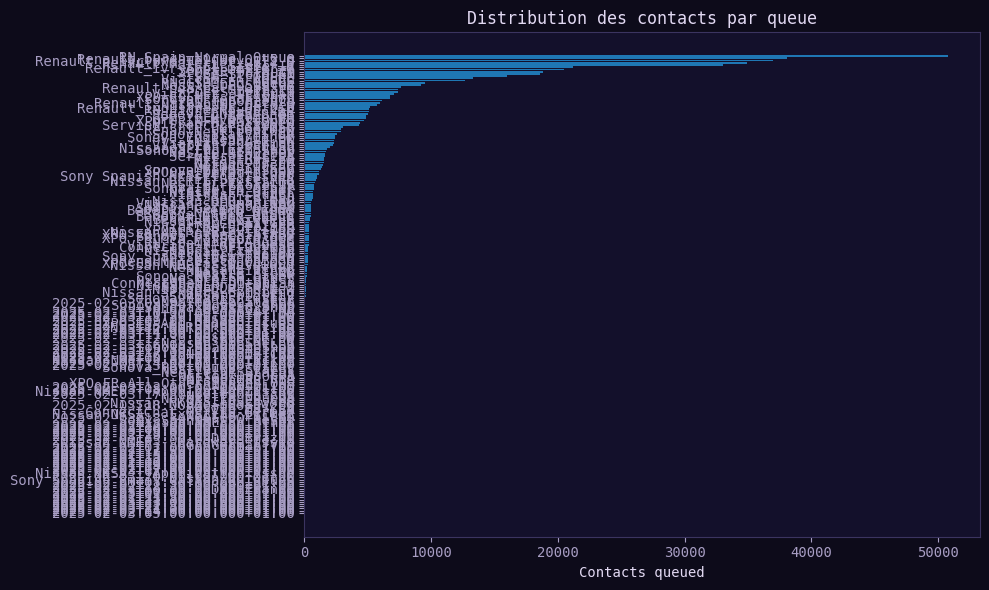

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/Telephony_Data.csv', sep=';')

# Nettoyage colonnes
df.columns = df.columns.str.strip()

# La colonne queue s'appelle 'Queue', pas 'account'
# La colonne volume = 'Contacts queued' (pas 'offered')
volume_par_compte = (
    df.groupby('Queue')['Contacts queued']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
volume_par_compte['Part (%)'] = (
    volume_par_compte['Contacts queued'] / volume_par_compte['Contacts queued'].sum() * 100
).round(1)

print(f"Total contacts queued : {volume_par_compte['Contacts queued'].sum():,}")
display(volume_par_compte)

# Visualisation
plt.figure(figsize=(10, 6))
plt.barh(volume_par_compte['Queue'], volume_par_compte['Contacts queued'], color='#1f77b4')
plt.xlabel('Contacts queued')
plt.title('Distribution des contacts par queue')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

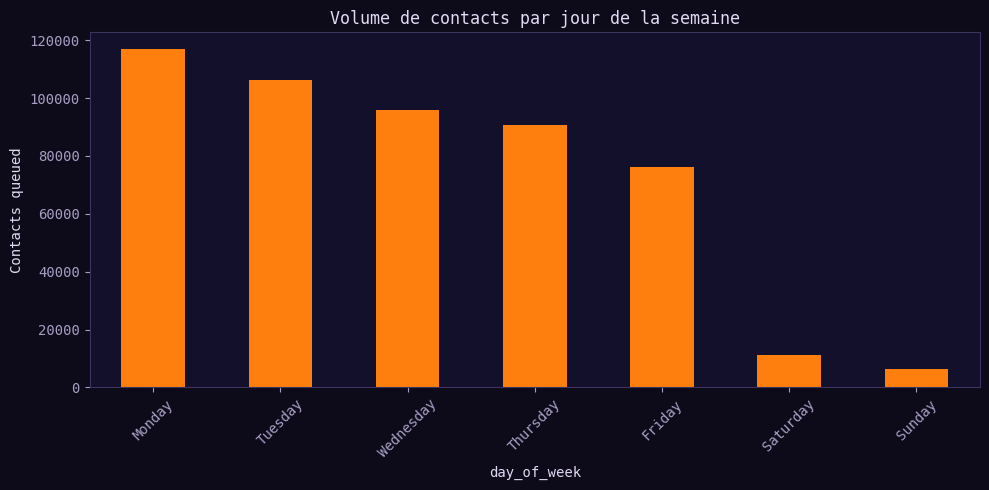

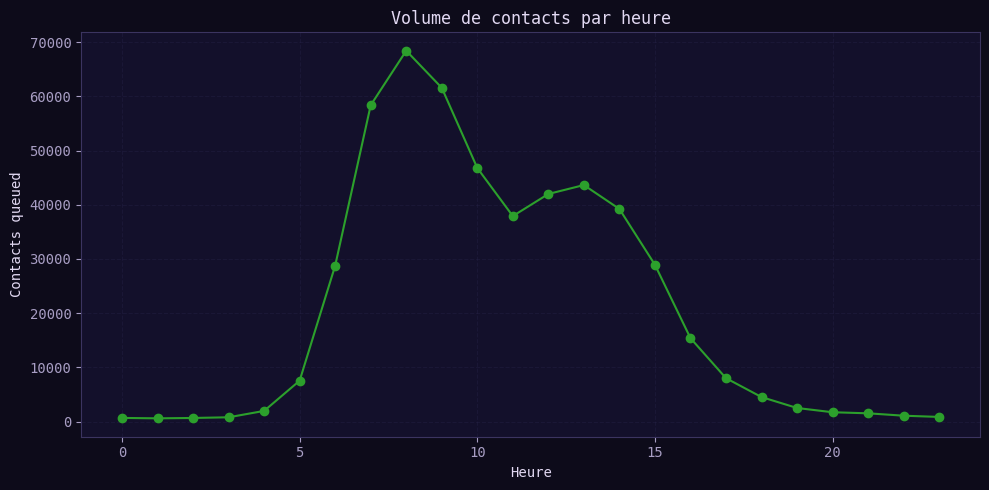

In [27]:
import matplotlib.pyplot as plt

# Conversion robuste avec gestion des valeurs corrompues
df['StartInterval'] = pd.to_datetime(df['StartInterval'], utc=True, errors='coerce')
df = df.dropna(subset=['StartInterval'])  # supprime les lignes avec "1" ou valeurs invalides
df['StartInterval'] = df['StartInterval'].dt.tz_localize(None)

df['day_of_week'] = df['StartInterval'].dt.day_name()
df['hour'] = df['StartInterval'].dt.hour

# --- Par jour de la semaine ---
ordre_jours = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
volume_par_jour = (
    df.groupby('day_of_week')['Contacts queued']
    .sum()
    .reindex(ordre_jours)
)

plt.figure(figsize=(10, 5))
volume_par_jour.plot(kind='bar', color='#ff7f0e')
plt.title("Volume de contacts par jour de la semaine")
plt.ylabel("Contacts queued")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- Par heure de la journée ---
volume_par_heure = df.groupby('hour')['Contacts queued'].sum()

plt.figure(figsize=(10, 5))
volume_par_heure.plot(kind='line', marker='o', color='#2ca02c')
plt.title("Volume de contacts par heure")
plt.xlabel("Heure")
plt.ylabel("Contacts queued")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

,account,SLA (%),Abandon (%),Objectif (%),Statut
10,Sony,85.3,5.6,NaN,N/A
3,GF/ConnectChat,87.4,4.3,80.0,Conforme
12,XPO,90.1,6.2,90.0,Conforme
4,Nestle,91.6,7.8,91.0,Conforme
9,Sonova,93.8,6.2,80.0,Conforme
11,Viatris,95.0,5.0,80.0,Conforme
5,Nissan,95.4,4.6,90.0,Conforme
6,Renault,95.4,4.6,90.0,Conforme
2,EL Store,96.0,4.0,90.0,Conforme
7,SPM,96.3,3.7,85.0,Conforme


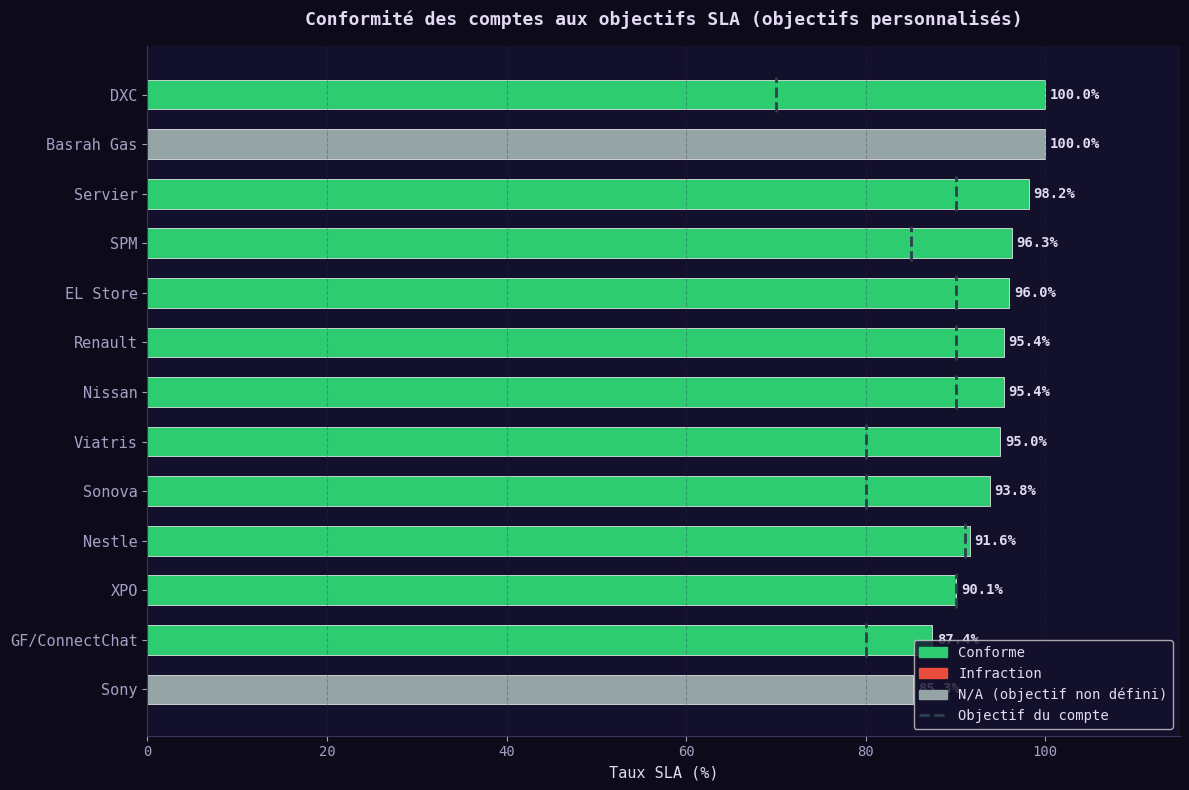

In [29]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

# ── 1. Mapping Queue → Account ───────────────────────────────────
def get_account(queue):
    q = str(queue).strip()
    if q.startswith('Nissan'):              return 'Nissan'
    if q.startswith('Servier'):             return 'Servier'
    if q.startswith('Renault') or q.startswith('RN_'): return 'Renault'
    if q.startswith('Sony'):               return 'Sony'
    if q.startswith('Sonova'):             return 'Sonova'
    if q.startswith('Nestle'):             return 'Nestle'
    if q.startswith('XPO'):               return 'XPO'
    if q.startswith('Viatris'):            return 'Viatris'
    if q.startswith('Mylan'):              return 'Viatris'   # Mylan = Viatris
    if q.startswith('Benelux'):            return 'Renault'   # Benelux = Renault
    if q.startswith('Nordic'):             return 'Renault'   # Nordic = Renault
    if q.startswith('GF') or q.startswith('ConnectChat') or q.startswith('German'): return 'GF/ConnectChat'
    if q.startswith('EL Store'):           return 'EL Store'
    if q.startswith('SPM'):               return 'SPM'
    if q.startswith('DXC'):               return 'DXC'
    if q.startswith('Basrah'):             return 'Basrah Gas'
    return 'Autre'

df['account'] = df['Queue'].apply(get_account)

# ── 2. Conversion numérique ──────────────────────────────────────
cols_num = ['Contacts queued', 'Contacts handled incoming', 'Contacts abandoned', 'Service level 60 seconds']
for col in cols_num:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# ── 3. Objectifs SLA par compte (source: SLA.xlsx) ───────────────
SLA_OBJECTIFS = {
    'Nissan':         90.0,
    'Servier':        90.0,
    'Renault':        90.0,   # inclut Benelux, Nordic, RN_*
    'Sonova':         80.0,
    'Nestle':         91.0,
    'XPO':            90.0,
    'Viatris':        80.0,   # inclut Mylan
    'GF/ConnectChat': 80.0,
    'EL Store':       90.0,
    'DXC':            70.0,
    'Basrah Gas':     None,   # NA dans le fichier
    'SPM':            85.0,
    'Sony':           None,   # objectif en secondes ASA, pas en %
    'Autre':          80.0,   # fallback
}
DEFAULT_OBJECTIF = 80.0

# ── 4. Agrégation par compte ─────────────────────────────────────
sla_par_compte = df.groupby('account').agg(
    offered_total=('Contacts queued', 'sum'),
    answered_total=('Contacts handled incoming', 'sum'),
    abandoned_total=('Contacts abandoned', 'sum'),
    sla_60_mean=('Service level 60 seconds', 'mean')
).reset_index()

sla_par_compte['SLA (%)'] = (
    sla_par_compte['answered_total'] / sla_par_compte['offered_total'] * 100
).round(1)

sla_par_compte['Abandon (%)'] = (
    sla_par_compte['abandoned_total'] / sla_par_compte['offered_total'] * 100
).round(1)

# ── 5. Objectif et statut par compte ─────────────────────────────
sla_par_compte['Objectif (%)'] = sla_par_compte['account'].map(
    lambda a: SLA_OBJECTIFS.get(a, DEFAULT_OBJECTIF)
)

sla_par_compte['Statut'] = sla_par_compte.apply(
    lambda row: 'N/A' if pd.isna(row['Objectif (%)'])
    else ('Conforme' if row['SLA (%)'] >= row['Objectif (%)'] else 'Infraction'),
    axis=1
)

sla_plot = sla_par_compte.sort_values('SLA (%)', ascending=True)
display(sla_plot[['account', 'SLA (%)', 'Abandon (%)', 'Objectif (%)', 'Statut']])

# ── 6. Visualisation ─────────────────────────────────────────────
color_map = {'Conforme': '#2ecc71', 'Infraction': '#e74c3c', 'N/A': '#95a5a6'}
colors = sla_plot['Statut'].map(color_map)

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(range(len(sla_plot)), sla_plot['SLA (%)'],
        color=colors, edgecolor='white', linewidth=0.5, height=0.6)

# Tiret vertical = objectif propre à chaque compte
for i, (_, row) in enumerate(sla_plot.iterrows()):
    if pd.notna(row['Objectif (%)']):
        ax.plot([row['Objectif (%)'], row['Objectif (%)']],
                [i - 0.35, i + 0.35],
                color='#2c3e50', linewidth=2, linestyle='--')

# Labels valeurs
for i, val in enumerate(sla_plot['SLA (%)']):
    ax.text(val + 0.5, i, f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')

ax.set_yticks(range(len(sla_plot)))
ax.set_yticklabels(sla_plot['account'], fontsize=11)
ax.set_xlabel('Taux SLA (%)', fontsize=11)
ax.set_xlim(0, 115)
ax.set_title('Conformité des comptes aux objectifs SLA (objectifs personnalisés)',
             fontsize=13, fontweight='bold', pad=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', alpha=0.3, linestyle='--')

conforme_patch  = mpatches.Patch(color='#2ecc71', label='Conforme')
infraction_patch = mpatches.Patch(color='#e74c3c', label='Infraction')
na_patch        = mpatches.Patch(color='#95a5a6', label='N/A (objectif non défini)')
objectif_line   = plt.Line2D([0], [0], color='#2c3e50', linestyle='--',
                              linewidth=2, label='Objectif du compte')
ax.legend(handles=[conforme_patch, infraction_patch, na_patch, objectif_line],
          loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig('sla_par_compte.png', dpi=150, bbox_inches='tight')
plt.show()